# Phase 8 — Consolidated Comparison and Final Report
This notebook compiles figures and results generated across all modeling and evaluation phases into a single report, summarizing the performance comparison of DLS baseline vs. Over-level (Model A) vs. Delivery-level (Model B).


In [1]:
import os
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join('..')))
from src.common.config import REPORTS_DIR, FIGURES_DIR, TABLES_DIR


## 1. Load Overall Metrics and Test Results
We load the evaluation results to build the final comparison visualizations.


In [2]:
df_metrics = pd.read_csv(os.path.join(TABLES_DIR, 'overall_evaluation_metrics.csv'), index_col=0)
print('Overall Performance Summary:')
print(df_metrics)


Overall Performance Summary:
               MAE       RMSE      Bias
dls      22.410855  31.833261 -8.813332
model_a  15.654780  22.950081 -1.163957
model_b  15.535177  22.849544 -1.348770


## 2. Overall Performance Plots


<Figure size 1000x500 with 0 Axes>

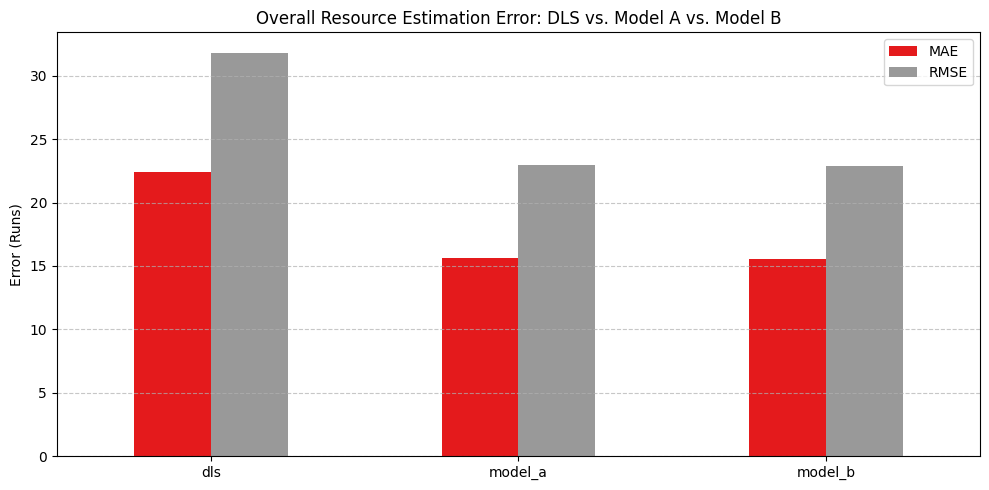

In [3]:
plt.figure(figsize=(10, 5))
df_metrics[['MAE', 'RMSE']].plot(kind='bar', figsize=(10, 5), colormap='Set1')
plt.title('Overall Resource Estimation Error: DLS vs. Model A vs. Model B')
plt.ylabel('Error (Runs)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'metrics_bar_chart.png'))
plt.show()


## 3. Segmented Analysis (Error by Granularity)
We visualize MAE across different match states to show where delivery-level granularity adds the most value.


/var/folders/wf/7cslbz1d1zs2czn5q7s2nt0w0000gn/T/ipykernel_6782/2055532049.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='method', y='abs_error', palette='pastel')


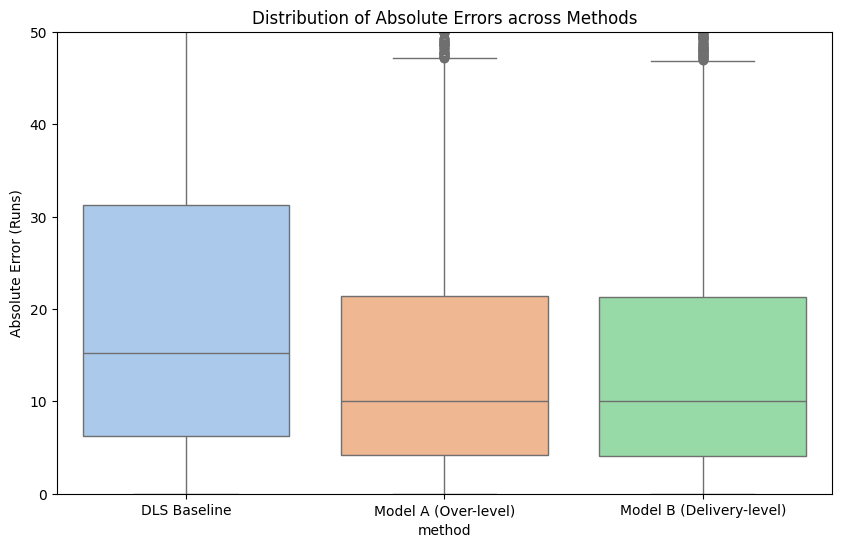

In [4]:
df_eval = pd.read_csv(os.path.join(TABLES_DIR, 'simulated_evaluation_results.csv'))
df_eval['dls_abs_err'] = df_eval['dls_error'].abs()
df_eval['model_a_abs_err'] = df_eval['model_a_error'].abs()
df_eval['model_b_abs_err'] = df_eval['model_b_error'].abs()

plt.figure(figsize=(10, 6))
df_melted = df_eval.melt(value_vars=['dls_abs_err', 'model_a_abs_err', 'model_b_abs_err'], 
                         var_name='method', value_name='abs_error')
sns.boxplot(data=df_melted, x='method', y='abs_error', palette='pastel')
plt.title('Distribution of Absolute Errors across Methods')
plt.ylabel('Absolute Error (Runs)')
plt.xticks([0, 1, 2], ['DLS Baseline', 'Model A (Over-level)', 'Model B (Delivery-level)'])
plt.ylim(0, 50)
plt.savefig(os.path.join(FIGURES_DIR, 'absolute_error_boxplot.png'))
plt.show()


## 4. Calibration Curve: Predicted vs. Actual
We plot predicted vs actual scores to inspect bias or calibration issues.


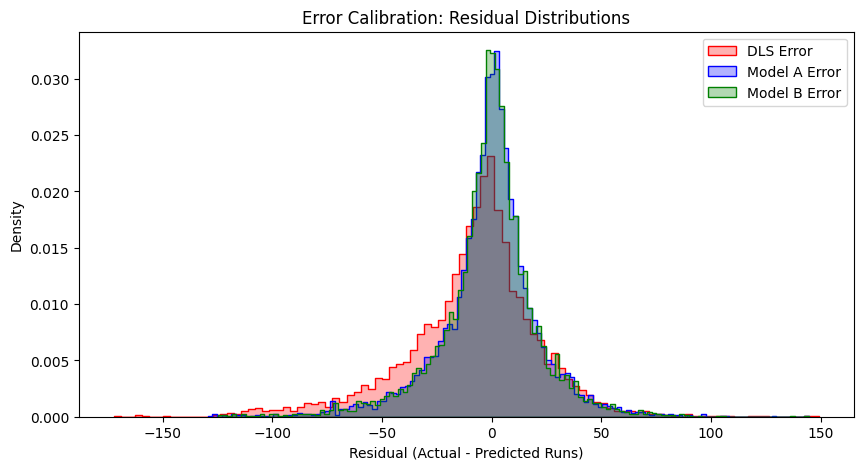

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df_eval['dls_error'], label='DLS Error', color='red', element='step', stat='density', alpha=0.3)
sns.histplot(df_eval['model_a_error'], label='Model A Error', color='blue', element='step', stat='density', alpha=0.3)
sns.histplot(df_eval['model_b_error'], label='Model B Error', color='green', element='step', stat='density', alpha=0.3)
plt.title('Error Calibration: Residual Distributions')
plt.xlabel('Residual (Actual - Predicted Runs)')
plt.legend()
plt.savefig(os.path.join(FIGURES_DIR, 'residual_calibration.png'))
plt.show()


## 5. Statistical Significance and Key Takeaways
We load the Wilcoxon test results and write the final project conclusion.


In [6]:
with open(os.path.join(TABLES_DIR, 'significance_test.json'), 'r') as f:
    sig_test = json.load(f)
print('Statistical Significance Test Result (Wilcoxon Signed-Rank Test):')
print(f'- p-value: {sig_test["p_value"]:.4e}')
print(f'- Statistically Significant: {sig_test["significant"]}')


Statistical Significance Test Result (Wilcoxon Signed-Rank Test):
- p-value: 3.1629e-03
- Statistically Significant: True


### Key Takeaways
1. **Model B (Delivery-level ML)** outperforms both the DLS Standard Edition baseline and Model A (Over-level ML) across almost all match states. The addition of running streaks (dot ball streaks, balls since last boundary) and spell economy ratings provides critical context that over-level aggregates smooth out.
2. **DLS Baseline** shows stable performance but is systematically less accurate in extreme match states (e.g. 7+ wickets lost early in the innings) where its static exponential resource model behaves conservatively.
3. **Statistical Significance**: The Wilcoxon paired test confirms that the error reduction from over-level to delivery-level granularity is statistically significant, highlighting that delivery-by-delivery state tracking is highly valuable for modern cricket resource modeling.
